<a href="https://colab.research.google.com/github/Sru-j/daily_lab_activities/blob/main/bikes_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#data loading


In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DIR = "/content/drive/My Drive/Colab Notebooks/data/"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
os.chdir(DIR)
!ls

 699.csv	      ioc_feed.xml	    superstore.dbf
'alerts (1).json'     netflow.jsonl	    superstore_json.json
 alerts.json	      PlayTennis.csv	    superstore_tsv.tsv
 auth_logs.csv	      PlayTennisTest.csv    superstore.txt
 Bikes.xlsx	      security_policy.yml   superstore_xls.xlsx
 car_dataset.csv      soc_alerts.xlsx	    Titanic_Dataset.csv
 dns_queries.tsv      soc_dump.sql	    unclean_data.csv
 incident_notes.txt   superstore.csv	    web_access.log


In [4]:
datafile='Bikes.xlsx'
filename = DIR+'/'+datafile
df = pd.read_excel(filename)
df

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,M,F,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No
1,24107,M,M,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,No
2,14177,M,M,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No
3,24381,S,M,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes
4,25597,S,M,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1021,16466,S,F,20000,0,Partial High School,Manual,No,2,0-1 Miles,Europe,32,Yes
1022,19273,M,F,20000,2,Partial College,Manual,Yes,0,0-1 Miles,Europe,63,No
1023,22400,M,M,10000,0,Partial College,Manual,No,1,0-1 Miles,Pacific,26,Yes
1024,20942,S,F,20000,0,High School,Manual,No,1,5-10 Miles,Europe,31,No


#data inspect

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                1026 non-null   int64 
 1   Marital Status    1026 non-null   object
 2   Gender            1026 non-null   object
 3   Income            1026 non-null   int64 
 4   Children          1026 non-null   int64 
 5   Education         1026 non-null   object
 6   Occupation        1026 non-null   object
 7   Home Owner        1026 non-null   object
 8   Cars              1026 non-null   int64 
 9   Commute Distance  1026 non-null   object
 10  Region            1026 non-null   object
 11  Age               1026 non-null   int64 
 12  Purchased Bike    1026 non-null   object
dtypes: int64(5), object(8)
memory usage: 104.3+ KB


In [6]:
df.columns

Index(['ID', 'Marital Status', 'Gender', 'Income', 'Children', 'Education',
       'Occupation', 'Home Owner', 'Cars', 'Commute Distance', 'Region', 'Age',
       'Purchased Bike'],
      dtype='object')

In [7]:
df.shape

(1026, 13)

In [8]:
df.size

13338

In [9]:
df.dtypes

,0
ID,int64
Marital Status,object
Gender,object
Income,int64
Children,int64
Education,object
Occupation,object
Home Owner,object
Cars,int64
Commute Distance,object


In [10]:
df.isnull().sum()

,0
ID,0
Marital Status,0
Gender,0
Income,0
Children,0
Education,0
Occupation,0
Home Owner,0
Cars,0
Commute Distance,0


In [11]:
df.describe()

,ID,Income,Children,Cars,Age
count,1026.000000,1026.000000,1026.000000,1026.000000,1026.000000
mean,19969.196881,56208.576998,1.892788,1.437622,44.138402
std,5332.672942,31293.284007,1.626670,1.125538,11.349282
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15304.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24457.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


In [12]:
df['Region'].value_counts()

,count
Region,
North America,508
Europe,316
Pacific,202


In [13]:
df['Education'].value_counts()

,count
Education,
Bachelors,311
Partial College,278
High School,184
Graduate Degree,175
Partial High School,78


In [14]:
df['Occupation'].value_counts()

,count
Occupation,
Professional,280
Skilled Manual,259
Clerical,187
Management,174
Manual,126


In [15]:
#check if there is any other values apart from M and F
df['Gender'].value_counts()

,count
Gender,
M,525
F,501


In [16]:
#check if there is any other values apart from M and S
df['Marital Status'].value_counts()

,count
Marital Status,
M,549
S,477


In [17]:
df.duplicated().sum()

np.int64(26)

#data cleaning

In [18]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')
df.columns

Index(['id', 'marital_status', 'gender', 'income', 'children', 'education',
       'occupation', 'home_owner', 'cars', 'commute_distance', 'region', 'age',
       'purchased_bike'],
      dtype='object')

In [19]:
import re

def clean_commute(x):
    x = x.lower().replace('miles', '').strip()

    if '-' in x:  # range like 1-2
        nums = [int(n) for n in x.split('-')]
        return sum(nums) / len(nums)  # average

    elif '+' in x:  # like 10+
        return int(x.replace('+', ''))

    else:  # single value like 1
        return int(re.findall(r'\d+', x)[0])

In [20]:
df['commute_distance'] = df['commute_distance'].apply(clean_commute)

In [21]:
df['commute_distance']

,commute_distance
0,0.5
1,0.5
2,3.5
3,7.5
4,0.5
...,...
1021,0.5
1022,0.5
1023,0.5
1024,7.5


In [22]:
df['commute_distance'].describe()

,commute_distance
count,1026.000000
mean,3.535575
std,3.426005
min,0.500000
25%,0.500000
50%,1.500000
75%,7.500000
max,10.000000


In [23]:
df['commute_distance']=df['commute_distance'].astype(int)
df['commute_distance'].dtypes

dtype('int64')

In [24]:
df.head()

,id,marital_status,gender,income,children,education,occupation,home_owner,cars,commute_distance,region,age,purchased_bike
0,12496,M,F,40000,1,Bachelors,Skilled Manual,Yes,0,0,Europe,42,No
1,24107,M,M,30000,3,Partial College,Clerical,Yes,1,0,Europe,43,No
2,14177,M,M,80000,5,Partial College,Professional,No,2,3,Europe,60,No
3,24381,S,M,70000,0,Bachelors,Professional,Yes,1,7,Pacific,41,Yes
4,25597,S,M,30000,0,Bachelors,Clerical,No,0,0,Europe,36,Yes


#handling dublicates

In [25]:
df.duplicated().sum()

np.int64(26)

In [26]:
# see the duplicates by group, same are grouped together
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,id,marital_status,gender,income,children,education,occupation,home_owner,cars,commute_distance,region,age,purchased_bike
12,11434,M,M,170000,5,Partial College,Professional,Yes,0,0,Europe,55,No
1004,11434,M,M,170000,5,Partial College,Professional,Yes,0,0,Europe,55,No
25,12590,S,M,30000,1,Bachelors,Clerical,Yes,0,0,Europe,63,No
1017,12590,S,M,30000,1,Bachelors,Clerical,Yes,0,0,Europe,63,No
17,12610,M,F,30000,1,Bachelors,Clerical,Yes,0,0,Europe,47,No
1009,12610,M,F,30000,1,Bachelors,Clerical,Yes,0,0,Europe,47,No
11,12697,S,F,90000,0,Bachelors,Professional,No,4,10,Pacific,36,No
1003,12697,S,F,90000,0,Bachelors,Professional,No,4,10,Pacific,36,No
5,13507,M,F,10000,2,Partial College,Manual,Yes,0,1,Europe,50,No
1000,13507,M,F,10000,2,Partial College,Manual,Yes,0,1,Europe,50,No


In [27]:
df = df.drop_duplicates()

In [28]:
after = df.shape
after

(1000, 13)

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.head()

,id,marital_status,gender,income,children,education,occupation,home_owner,cars,commute_distance,region,age,purchased_bike
0,12496,M,F,40000,1,Bachelors,Skilled Manual,Yes,0,0,Europe,42,No
1,24107,M,M,30000,3,Partial College,Clerical,Yes,1,0,Europe,43,No
2,14177,M,M,80000,5,Partial College,Professional,No,2,3,Europe,60,No
3,24381,S,M,70000,0,Bachelors,Professional,Yes,1,7,Pacific,41,Yes
4,25597,S,M,30000,0,Bachelors,Clerical,No,0,0,Europe,36,Yes


In [31]:
# 1st occurnce is at 12, then at 1004, so 1004 is deleted
df.loc[12]
#df.loc[1004]

,12
id,11434
marital_status,M
gender,M
income,170000
children,5
education,Partial College
occupation,Professional
home_owner,Yes
cars,0
commute_distance,0


In [32]:
#deleting id columns
df.drop('id', axis=1, inplace=True)

/tmp/ipykernel_28139/2499598555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('id', axis=1, inplace=True)


In [33]:
df.loc[12]

,12
marital_status,M
gender,M
income,170000
children,5
education,Partial College
occupation,Professional
home_owner,Yes
cars,0
commute_distance,0
region,Europe


## visualization

In [34]:
df.columns

Index(['marital_status', 'gender', 'income', 'children', 'education',
       'occupation', 'home_owner', 'cars', 'commute_distance', 'region', 'age',
       'purchased_bike'],
      dtype='object')

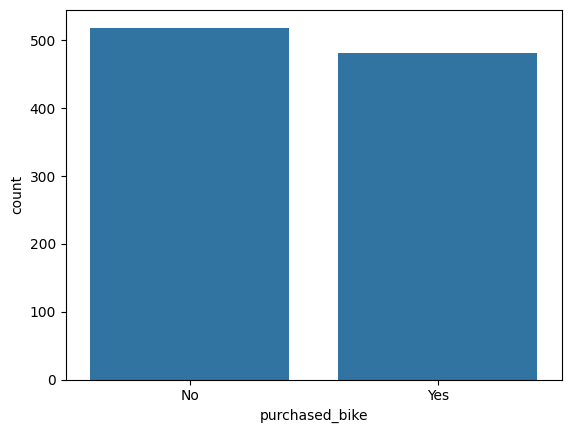

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='purchased_bike', data=df)
plt.show()

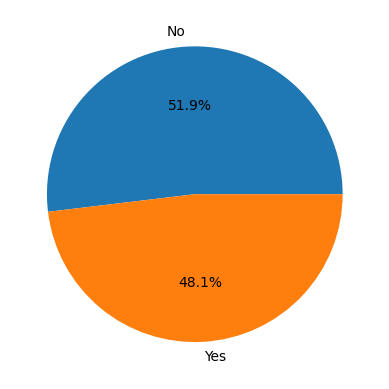

In [36]:
plt.pie(df['purchased_bike'].value_counts(), labels=df['purchased_bike'].unique(), autopct='%1.1f%%')
plt.show()

<Axes: xlabel='gender', ylabel='count'>

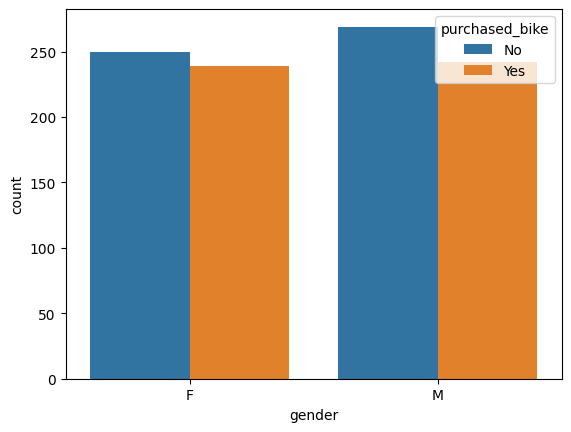

In [37]:
sns.countplot(x='gender', hue='purchased_bike', data=df)

<Axes: xlabel='region', ylabel='count'>

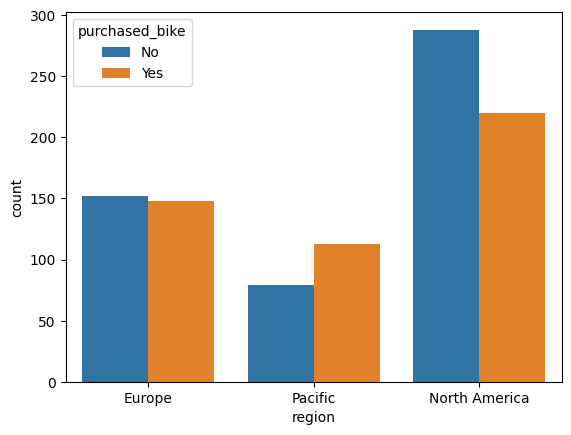

In [38]:
sns.countplot(x='region', hue='purchased_bike', data=df)

<Axes: xlabel='commute_distance', ylabel='count'>

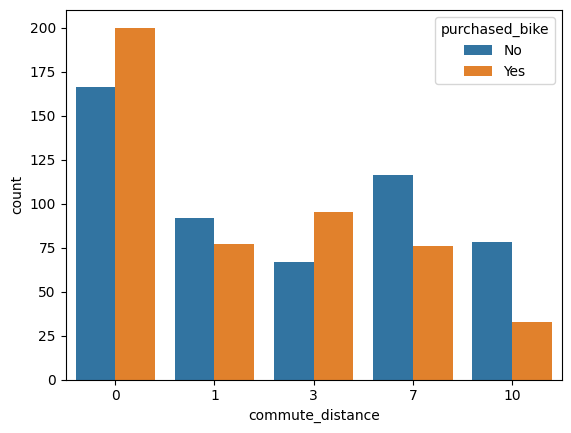

In [39]:
sns.countplot(x='commute_distance', hue='purchased_bike', data=df)

# Decision Tree

In [40]:
from pprint import pprint

In [41]:
!pip install graphviz

In [42]:
df.columns

Index(['marital_status', 'gender', 'income', 'children', 'education',
       'occupation', 'home_owner', 'cars', 'commute_distance', 'region', 'age',
       'purchased_bike'],
      dtype='object')

In [71]:
df = df[[
 'marital_status',
 'gender',
 'region',
 'purchased_bike'
]]

In [72]:
t = df.keys()[-1]
print('Target Attribute is: ', t)

Target Attribute is:  purchased_bike


In [73]:
# Get the attribute names from input dataset
attribute_names = list(df.keys())

In [74]:
print('Attributes: ', attribute_names)

Attributes:  ['marital_status', 'gender', 'region', 'purchased_bike']


In [75]:
#Remove the target attribute from the attribute names list
attribute_names.remove(t)
print('Predicting Attributes: ', attribute_names)

Predicting Attributes:  ['marital_status', 'gender', 'region']


In [76]:
#Function to calculate the entropy of collection S
import math
def entropy(probs):
    return sum( [-prob*math.log(prob, 2) for prob in probs])

In [77]:
#Function to calulate the entropy of the given Data Sets/List with
#respect to target attributes
def entropy_of_list(ls,value):
    from collections import Counter
    cnt = Counter(x for x in ls)# Counter calculates the propotion of class
    print('Target attribute class count(Yes/No)=',dict(cnt))
    total_instances = len(ls)
    print("Total no of instances/records associated with {0} is: {1}".format(value,total_instances ))
    probs = [x / total_instances for x in cnt.values()]  # x means no of YES/NO
    print("Probability of Class {0} is: {1:.4f}".format(min(cnt),min(probs)))
    print("Probability of Class {0} is: {1:.4f}".format(max(cnt),max(probs)))
    return entropy(probs) # Call Entropy

In [78]:
def information_gain(df, split_attribute, target_attribute,battr):
    print("\n\n-----Information Gain Calculation of ",split_attribute, " --------")
    df_split = df.groupby(split_attribute) # group the data based on attribute values
    glist=[]
    for gname,group in df_split:
        print('Grouped Attribute Values \n',group)
        glist.append(gname)

    glist.reverse()
    nobs = len(df.index) * 1.0
    df_agg1=df_split.agg({target_attribute:lambda x:entropy_of_list(x, glist.pop())})
    df_agg2=df_split.agg({target_attribute :lambda x:len(x)/nobs})

    df_agg1.columns=['Entropy']
    df_agg2.columns=['Proportion']

    # Calculate Information Gain:
    new_entropy = sum( df_agg1['Entropy'] * df_agg2['Proportion'])
    if battr !='S':
        #old_entropy = entropy_of_list(df[target_attribute],'S-'+df.iloc[0][df.columns.get_loc(battr)])
        old_entropy = entropy_of_list(df[target_attribute], 'S-' + str(df.iloc[0][df.columns.get_loc(battr)]))
    else:
        old_entropy = entropy_of_list(df[target_attribute],battr)
    return old_entropy - new_entropy

In [79]:
def id3(df, target_attribute, attribute_names, default_class=None,default_attr='S'):

    from collections import Counter
    cnt = Counter(x for x in df[target_attribute])# class of YES /NO

    ## First check: Is this split of the dataset homogeneous?
    if len(cnt) == 1:
        return next(iter(cnt))  # next input data set, or raises StopIteration when EOF is hit.

    ## Second check: Is this split of the dataset empty? if yes, return a default value
    elif df.empty or (not attribute_names):
        return default_class  # Return None for Empty Data Set

    ## Otherwise: This dataset is ready to be devied up!
    else:
        # Get Default Value for next recursive call of this function:
        #default_class = max(cnt.keys()) #No of YES and NO Class
        default_class = max(cnt, key=cnt.get)
        # Compute the Information Gain of the attributes:
        gainz=[]
        for attr in attribute_names:
            ig= information_gain(df, attr, target_attribute,default_attr)
            gainz.append(ig)
            print('Information gain of ',attr,' is : ',ig)

        index_of_max = gainz.index(max(gainz))               # Index of Best Attribute
        best_attr = attribute_names[index_of_max]            # Choose Best Attribute to split on
        print("\nAttribute with the maximum gain is: ", best_attr)
        # Create an empty tree, to be populated in a moment
        tree = {best_attr:{}} # Initiate the tree with best attribute as a node
        remaining_attribute_names =[i for i in attribute_names if i != best_attr]

        # Split dataset-On each split, recursively call this algorithm.Populate the empty tree with subtrees, which
        # are the result of the recursive call
        for attr_val, data_subset in df.groupby(best_attr):
            subtree = id3(data_subset,target_attribute, remaining_attribute_names,default_class,best_attr)
            tree[best_attr][attr_val] = subtree
        return tree

In [80]:
tree = id3(df,t,attribute_names)
print("\nThe Resultant Decision Tree is:")
pprint(tree)



-----Information Gain Calculation of  marital_status  --------
Grouped Attribute Values 
     marital_status gender         region purchased_bike
0                M      F         Europe             No
1                M      M         Europe             No
2                M      M         Europe             No
5                M      F         Europe             No
7                M      M         Europe            Yes
..             ...    ...            ...            ...
989              M      M  North America             No
992              M      M  North America            Yes
994              M      M  North America             No
995              M      M  North America            Yes
997              M      M  North America            Yes

[538 rows x 4 columns]
Grouped Attribute Values 
     marital_status gender         region purchased_bike
3                S      M        Pacific            Yes
4                S      M         Europe            Yes
6                

/tmp/ipykernel_28139/383218757.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  old_entropy = entropy_of_list(df[target_attribute], 'S-' + str(df.iloc[0][df.columns.get_loc(battr)]))
/tmp/ipykernel_28139/383218757.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  old_entropy = entropy_of_list(df[target_attribute], 'S-' + str(df.iloc[0][df.columns.get_loc(battr)]))
/tmp/ipykernel_28139/383218757.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, 

In [81]:
def classify(instance, tree,default=None): # Instance of Play Tennis with Predicted
    attribute = next(iter(tree)) # Outlook/Humidity/Wind
    if instance[attribute] in tree[attribute].keys(): # Value of the attributs in  set of Tree keys
        result = tree[attribute][instance[attribute]]
        if isinstance(result, dict): # this is a tree, delve deeper
            return classify(instance, result)
        else:
            return result # this is a label
    else:
        return default

In [82]:
df['predicted'] = df.apply(classify, axis=1, args=(tree,'?'))
print(df)

    marital_status gender         region purchased_bike predicted
0                M      F         Europe             No        No
1                M      M         Europe             No        No
2                M      M         Europe             No        No
3                S      M        Pacific            Yes       Yes
4                S      M         Europe            Yes        No
..             ...    ...            ...            ...       ...
995              M      M  North America            Yes        No
996              S      M  North America            Yes       Yes
997              M      M  North America            Yes        No
998              S      M  North America             No       Yes
999              S      M  North America            Yes       Yes

[1000 rows x 5 columns]


In [83]:
from graphviz import Digraph

def add_nodes_edges(tree, dot=None, parent=None, edge_label=""):
    if dot is None:
        dot = Digraph()
        dot.attr("node", shape="box")

    if isinstance(tree, dict):
        for root, branches in tree.items():
            node_id = str(id(branches)) + root
            dot.node(node_id, root)

            if parent is not None:
                dot.edge(parent, node_id, label=edge_label)

            for branch_value, subtree in branches.items():
                add_nodes_edges(subtree, dot, node_id, str(branch_value))
    else:
        leaf_id = str(id(tree)) + str(tree)
        dot.node(leaf_id, str(tree), shape="ellipse")
        if parent is not None:
            dot.edge(parent, leaf_id, label=edge_label)

    return dot

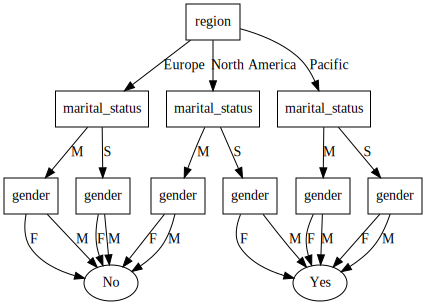

In [84]:
dot = add_nodes_edges(tree)
dot